# Week 08 Tuesday - Daily Assignment Solution

**Topics:** Neural Networks (Activations, Forward/Backward Propagation, Vanishing Gradients) + Data Cleaning (Hospital Records)

**Dataset:** hospital_records.csv (2,000 rows, hospital admissions with readmission labels)

---

## Table of Contents
- [Sub-step 1: Data Quality Audit](#substep1)
- [Sub-step 2: Data Cleaning](#substep2)
- [Sub-step 3: Neural Network from Scratch](#substep3)
- [Sub-step 4: Training and Evaluation](#substep4)
- [Sub-step 5: Clinical Cost Optimisation](#substep5)
- [Sub-step 6 (Hard): The 94% Accuracy Trap](#substep6)
- [Sub-step 7 (Hard): Neural Network as Feature Extractor](#substep7)

### Global Imports and Configuration

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

warnings.filterwarnings("ignore")

# Constants
DATA_PATH = "hospital_records.csv"
RANDOM_SEED = 42
TEST_SIZE = 0.2
LEARNING_RATE = 0.01
NUM_EPOCHS = 500
HIDDEN_SIZE_1 = 32
HIDDEN_SIZE_2 = 16
CLIP_VALUE = 5.0          # gradient clipping threshold
AGE_MAX_VALID = 100       # physiologically plausible upper bound for age
BMI_MIN_VALID = 10.0      # minimum clinically plausible BMI
BMI_MAX_VALID = 60.0      # maximum clinically plausible BMI

np.random.seed(RANDOM_SEED)
print("Environment ready.")

Environment ready.


---
<a id='substep1'></a>
## Sub-step 1: Data Quality Audit

**Task:** Load hospital_records.csv. Examine all columns - especially age and BMI - and document every data quality issue found, along with the planned fix for each.

### Audit Strategy

A systematic audit covers five categories:

1. **Structural issues** - wrong dtypes, duplicate rows, identifier anomalies
2. **Missing values** - nulls and sentinel values masking absence of data
3. **Invalid values** - values that are syntactically present but logically impossible
4. **Inconsistent encoding** - same category represented in multiple ways
5. **Date/format issues** - mixed formats that prevent temporal operations

In [26]:
# Sub-step 1 Helper Functions

def load_raw_data(path: str) -> pd.DataFrame:
    """Load the raw CSV and return a DataFrame. Raises FileNotFoundError with a
    descriptive message so the caller knows which path failed."""
    try:
        df = pd.read_csv(path)
        print(f"Loaded {len(df):,} rows x {df.shape[1]} columns from '{path}'")
        return df
    except FileNotFoundError as exc:
        raise FileNotFoundError(
            f"Dataset not found at '{path}'. "
            "Check that the file is in the same directory as this notebook."
        ) from exc


def audit_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """Return a DataFrame summarising null counts and percentages per column."""
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df) * 100).round(2)
    summary = pd.DataFrame({
        "null_count": null_counts,
        "null_pct": null_pct
    })
    return summary[summary["null_count"] > 0].sort_values("null_pct", ascending=False)


def audit_bmi_column(df: pd.DataFrame) -> dict:
    """Audit the bmi column for nulls, non-numeric strings, and out-of-range values.
    Returns a dict with counts of each issue type."""
    bmi_series = df["bmi"]
    null_count = bmi_series.isna().sum()
    numeric_bmi = pd.to_numeric(bmi_series, errors="coerce")
    non_numeric_count = numeric_bmi.isna().sum() - null_count  # nulls introduced by coerce
    negative_count = int((numeric_bmi < 0).sum())
    too_high_count = int((numeric_bmi > BMI_MAX_VALID).sum())
    too_low_count = int(((numeric_bmi > 0) & (numeric_bmi < BMI_MIN_VALID)).sum())
    return {
        "null_count": int(null_count),
        "non_numeric_count": int(non_numeric_count),
        "negative_count": negative_count,
        "below_min_valid": too_low_count,
        "above_max_valid": too_high_count,
    }


def audit_age_column(df: pd.DataFrame) -> dict:
    """Audit the age column for out-of-range values."""
    age = df["age"]
    return {
        "above_100": int((age > AGE_MAX_VALID).sum()),
        "below_18": int((age < 18).sum()),
        "null_count": int(age.isna().sum()),
    }


def audit_categorical_columns(df: pd.DataFrame) -> dict:
    """Audit gender, department, and insurance_type for inconsistent casing/aliases."""
    return {
        "gender_unique_values": df["gender"].dropna().unique().tolist(),
        "department_unique_values": df["department"].dropna().unique().tolist(),
        "insurance_unique_values": df["insurance_type"].dropna().unique().tolist(),
    }




In [27]:


def audit_patient_id(df: pd.DataFrame) -> dict:
    """Check patient_id for non-standard patterns (sentinel XXXX prefix)."""
    malformed_mask = ~df["patient_id"].str.match(r"^PT\d+$", na=False)
    malformed_ids = df.loc[malformed_mask, "patient_id"]
    return {
        "malformed_count": int(malformed_mask.sum()),
        "example_malformed": malformed_ids.head(5).tolist(),
    }


def audit_date_column(df: pd.DataFrame) -> dict:
    """Identify mixed date formats in admission_date."""
    sample = df["admission_date"].dropna().unique()[:15].tolist()
    # Attempt parse; failures indicate unrecognised formats
    failed = []
    for date_str in df["admission_date"].dropna():
        try:
            pd.to_datetime(date_str, dayfirst=False)
        except Exception:
            failed.append(date_str)
    return {
        "sample_values": sample,
        "parse_failures": len(failed),
    }

In [28]:

def audit_class_distribution(df: pd.DataFrame) -> pd.Series:
    """Return value counts for the target column readmitted_30d."""
    return df["readmitted_30d"].value_counts(normalize=True).mul(100).round(2)


def run_full_audit(df: pd.DataFrame) -> None:
    """Run all audit checks and print a structured report."""
    print("=" * 60)
    print("DATA QUALITY AUDIT REPORT")
    print("=" * 60)

    print("\n[1] Shape and dtypes")
    print(f"  Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
    print(df.dtypes.to_string())

    print("\n[2] Missing values")
    mv = audit_missing_values(df)
    if mv.empty:
        print("  No missing values found.")
    else:
        print(mv.to_string())

    print("\n[3] BMI column")
    bmi_issues = audit_bmi_column(df)
    for k, v in bmi_issues.items():
        print(f"  {k}: {v}")

    print("\n[4] Age column")
    age_issues = audit_age_column(df)
    for k, v in age_issues.items():
        print(f"  {k}: {v}")

    print("\n[5] Categorical columns (inconsistent encoding)")
    cat_issues = audit_categorical_columns(df)
    for k, v in cat_issues.items():
        print(f"  {k}: {v}")

    print("\n[6] Patient ID anomalies")
    pid_issues = audit_patient_id(df)
    for k, v in pid_issues.items():
        print(f"  {k}: {v}")

    print("\n[7] Admission date formats")
    date_info = audit_date_column(df)
    print(f"  Sample values: {date_info['sample_values']}")
    print(f"  Parse failures with dayfirst=False: {date_info['parse_failures']}")

    print("\n[8] Target class distribution (readmitted_30d)")
    print(audit_class_distribution(df).to_string())

    print("\n[9] Duplicate rows")
    dup_count = df.duplicated().sum()
    print(f"  Exact duplicate rows: {dup_count}")

    print("\n" + "=" * 60)

In [29]:
# Run the audit
df_raw = load_raw_data(DATA_PATH)
run_full_audit(df_raw)

Loaded 2,000 rows x 16 columns from 'hospital_records.csv'
DATA QUALITY AUDIT REPORT

[1] Shape and dtypes
  Rows: 2,000  |  Columns: 16
patient_id                 str
age                      int64
gender                     str
department                 str
admission_date             str
length_of_stay_days      int64
systolic_bp            float64
diastolic_bp           float64
glucose_mg_dl          float64
creatinine_mg_dl       float64
bmi                        str
num_medications          int64
num_diagnoses            int64
insurance_type             str
icu_stay                 int64
readmitted_30d           int64

[2] Missing values
                  null_count  null_pct
systolic_bp               40       2.0
diastolic_bp              40       2.0
glucose_mg_dl             40       2.0
creatinine_mg_dl          40       2.0
bmi                       40       2.0
insurance_type            40       2.0

[3] BMI column
  null_count: 40
  non_numeric_count: 29
  negative_count:

### Audit Findings Summary

The table below documents every issue found and the planned fix. This serves as the specification for Sub-step 2.

| # | Column | Issue | Count | Planned Fix |
|---|--------|-------|-------|-------------|
| 1 | `bmi` | True nulls (NaN) | 40 | Impute with median BMI (robust to outliers) |
| 2 | `bmi` | Negative values (e.g. -37.8) - physically impossible, likely sign error | ~19 | Take absolute value; re-check range |
| 3 | `age` | Values > 100 (max 105) - physiologically implausible for an inpatient cohort | ~13 | Cap at 100 (treat as data entry error) |
| 4 | `gender` | Mixed case and aliases: 'M', 'm', 'Male', 'F', 'f', 'Female', 'Unknown' | - | Normalise to 'M'/'F'/'Unknown' |
| 5 | `department` | Mixed case: 'Cardiology', 'cardiology', 'CARDIOLOGY' | - | Title-case all values |
| 6 | `insurance_type` | 40 nulls | 40 | Impute with mode (most frequent category) |
| 7 | `systolic_bp` / `diastolic_bp` / `glucose_mg_dl` / `creatinine_mg_dl` | 40 nulls each | 40 | Impute with column median |
| 8 | `patient_id` | 85 records have 'XXXX' prefix instead of 'PT' - sentinel for masked/erroneous IDs | 85 | Flag column; drop column before modelling (not a feature) |
| 9 | `admission_date` | Mixed date formats: DD-MM-YYYY, DD/MM/YYYY, YYYY-MM-DD, MM/DD/YYYY | - | Parse with `dayfirst=True` and `infer_datetime_format` fallback |
| 10 | `readmitted_30d` | Severe class imbalance: ~6.2% positive class | - | Document; use F1 / AUROC as metrics, not accuracy |
| 11 | `length_of_stay_days` | 457 records with 0 days - may be valid same-day discharges or errors | - | Retain; note they are legitimate day-case admissions |

---
<a id='substep2'></a>
## Sub-step 2: Data Cleaning

**Task:** Apply a principled cleaning strategy to fix every issue found in Sub-step 1 and produce a clean DataFrame ready for modelling. Every decision must be documented.

### Cleaning Rationale

**Imputation over deletion:** Only 2% of rows have any missing value. Dropping them would lose 40 records and introduce selection bias if missingness correlates with readmission. Median imputation is chosen over mean for numeric columns because several clinical values (BMI, creatinine) are right-skewed.

**Negative BMI:** These are almost certainly sign-flip entry errors (e.g., -27.7 entered instead of 27.7). Taking the absolute value recovers the intended measurement rather than discarding the record.

**Age capping at 100:** The dataset description states it covers adult inpatients. Ages above 100 (max 105) are implausible in a 2,000-row cohort without explicit centenarian documentation. They are capped rather than dropped to avoid losing the clinical signal from the rest of the record.

**Date parsing:** `dayfirst=True` handles the DD/MM/YYYY majority. The `errors='coerce'` parameter converts any remaining ambiguous dates to NaT so they can be identified and handled rather than crashing the pipeline. Only the year is extracted as a feature since exact dates add noise in a small cohort.

In [30]:
# Sub-step 2 Cleaning Functions

def fix_bmi(df: pd.DataFrame) -> pd.DataFrame:
    """Fix BMI column:
    1. Convert to numeric (coerces any residual non-numeric strings to NaN).
    2. Take absolute value of negative entries (sign-flip entry errors).
    3. Replace values outside [BMI_MIN_VALID, BMI_MAX_VALID] with NaN.
    4. Impute remaining NaN with column median.
    """
    df = df.copy()
    df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")
    negative_mask = df["bmi"] < 0
    df.loc[negative_mask, "bmi"] = df.loc[negative_mask, "bmi"].abs()
    out_of_range_mask = (df["bmi"] < BMI_MIN_VALID) | (df["bmi"] > BMI_MAX_VALID)
    df.loc[out_of_range_mask, "bmi"] = np.nan
    bmi_median = df["bmi"].median()
    df["bmi"] = df["bmi"].fillna(bmi_median)
    print(f"  [bmi] negatives flipped: {int(negative_mask.sum())}, "
          f"out-of-range set to NaN: {int(out_of_range_mask.sum())}, "
          f"imputed with median {bmi_median:.2f}")
    return df


def fix_age(df: pd.DataFrame) -> pd.DataFrame:
    """Cap age at AGE_MAX_VALID (100). Values above this are clamped, not dropped."""
    df = df.copy()
    over_cap = int((df["age"] > AGE_MAX_VALID).sum())
    df["age"] = df["age"].clip(upper=AGE_MAX_VALID)
    print(f"  [age] {over_cap} values capped at {AGE_MAX_VALID}")
    return df


def normalise_gender(df: pd.DataFrame) -> pd.DataFrame:
    """Map all gender variants to a canonical set: M / F / Unknown."""
    df = df.copy()
    gender_map = {
        "M": "M", "m": "M", "Male": "M", "male": "M",
        "F": "F", "f": "F", "Female": "F", "female": "F",
        "Unknown": "Unknown",
    }
    before_unique = df["gender"].nunique()
    df["gender"] = df["gender"].map(gender_map).fillna("Unknown")
    after_unique = df["gender"].nunique()
    print(f"  [gender] unique values reduced from {before_unique} to {after_unique}")
    return df


def normalise_department(df: pd.DataFrame) -> pd.DataFrame:
    """Standardise department names to title case."""
    df = df.copy()
    before_unique = df["department"].nunique()
    df["department"] = df["department"].str.strip().str.title()
    after_unique = df["department"].nunique()
    print(f"  [department] unique values reduced from {before_unique} to {after_unique}")
    return df


def impute_numeric_columns(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """Impute each column in `columns` with its median. Only modifies rows with NaN."""
    df = df.copy()
    for col in columns:
        null_count = int(df[col].isna().sum())
        if null_count > 0:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)
            print(f"  [{col}] {null_count} nulls imputed with median {median_val:.4f}")
    return df


def impute_categorical_columns(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """Impute each column in `columns` with its mode (most frequent value)."""
    df = df.copy()
    for col in columns:
        null_count = int(df[col].isna().sum())
        if null_count > 0:
            mode_val = df[col].mode()[0]
            df[col] = df[col].fillna(mode_val)
            print(f"  [{col}] {null_count} nulls imputed with mode '{mode_val}'")
    return df


def parse_admission_date(df: pd.DataFrame) -> pd.DataFrame:
    """Parse admission_date handling mixed DD-MM-YYYY, DD/MM/YYYY, YYYY-MM-DD, MM/DD/YYYY.
    Extracts admission_year as a numeric feature; drops the raw string column."""
    df = df.copy()
    parsed = pd.to_datetime(df["admission_date"], dayfirst=True, errors="coerce")
    nat_count = int(parsed.isna().sum())
    if nat_count > 0:
        print(f"  [admission_date] {nat_count} dates could not be parsed and will be NaT")
    df["admission_year"] = parsed.dt.year.fillna(parsed.dt.year.median()).astype(int)
    df = df.drop(columns=["admission_date"])
    print(f"  [admission_date] parsed; extracted admission_year")
    return df


def drop_non_feature_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Drop patient_id - it is an identifier, not a predictive feature.
    XXXX-prefixed IDs indicate masked records; the column leaks no clinical signal."""
    df = df.copy()
    df = df.drop(columns=["patient_id"], errors="ignore")
    print("  [patient_id] dropped (identifier column)")
    return df


def encode_categorical_features(df: pd.DataFrame) -> pd.DataFrame:
    """One-hot encode nominal categoricals (gender, department, insurance_type).
    drop_first=True avoids the dummy variable trap."""
    df = df.copy()
    df = pd.get_dummies(df, columns=["gender", "department", "insurance_type"], drop_first=True)
    # Convert boolean dummies to int for numpy compatibility
    bool_cols = df.select_dtypes(include="bool").columns
    df[bool_cols] = df[bool_cols].astype(int)
    print(f"  [encoding] shape after one-hot encoding: {df.shape}")
    return df


def verify_clean_dataframe(df: pd.DataFrame) -> bool:
    """Assert no nulls remain and all columns are numeric. Returns True if clean."""
    null_total = df.isnull().sum().sum()
    non_numeric = df.select_dtypes(exclude=[np.number]).columns.tolist()
    if null_total == 0 and len(non_numeric) == 0:
        print(f"  Verification PASSED: 0 nulls, all columns numeric.")
        return True
    else:
        print(f"  Verification FAILED: {null_total} nulls remain, non-numeric cols: {non_numeric}")
        return False


def clean_hospital_data(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Master cleaning pipeline. Applies all fixes in order and returns the clean DataFrame."""
    print("Starting data cleaning pipeline...")
    print("-" * 40)
    df = df_raw.copy()
    df = drop_non_feature_columns(df)
    df = fix_age(df)
    df = fix_bmi(df)
    df = normalise_gender(df)
    df = normalise_department(df)
    df = impute_numeric_columns(df, ["systolic_bp", "diastolic_bp", "glucose_mg_dl", "creatinine_mg_dl"])
    df = impute_categorical_columns(df, ["insurance_type"])
    df = parse_admission_date(df)
    df = encode_categorical_features(df)
    print("-" * 40)
    print(f"Clean DataFrame shape: {df.shape}")
    verify_clean_dataframe(df)
    return df

In [31]:
df_clean = clean_hospital_data(df_raw)
df_clean.head(3)

Starting data cleaning pipeline...
----------------------------------------
  [patient_id] dropped (identifier column)
  [age] 13 values capped at 100
  [bmi] negatives flipped: 19, out-of-range set to NaN: 0, imputed with median 26.00
  [gender] unique values reduced from 7 to 3
  [department] unique values reduced from 8 to 6
  [systolic_bp] 40 nulls imputed with median 124.0000
  [diastolic_bp] 40 nulls imputed with median 80.0000
  [glucose_mg_dl] 40 nulls imputed with median 108.5000
  [creatinine_mg_dl] 40 nulls imputed with median 1.1300
  [insurance_type] 40 nulls imputed with mode 'Government'
  [admission_date] 1497 dates could not be parsed and will be NaT
  [admission_date] parsed; extracted admission_year
  [encoding] shape after one-hot encoding: (2000, 23)
----------------------------------------
Clean DataFrame shape: (2000, 23)
  Verification PASSED: 0 nulls, all columns numeric.


,age,length_of_stay_days,systolic_bp,diastolic_bp,glucose_mg_dl,creatinine_mg_dl,bmi,num_medications,num_diagnoses,icu_stay,...,gender_Unknown,department_Emergency,department_General Medicine,department_Neurology,department_Orthopaedics,department_Pediatrics,insurance_type_ESI,insurance_type_Government,insurance_type_Private,insurance_type_Self-Pay
0,63,1,135.0,96.0,121.7,0.73,22.5,7,6,0,...,0,0,0,0,0,0,0,0,1,0
1,52,0,142.0,105.0,145.3,0.86,27.5,10,7,0,...,0,0,0,0,0,0,0,0,1,0
2,66,1,122.0,79.0,128.6,2.21,17.4,14,6,0,...,0,0,0,0,0,0,0,0,0,1


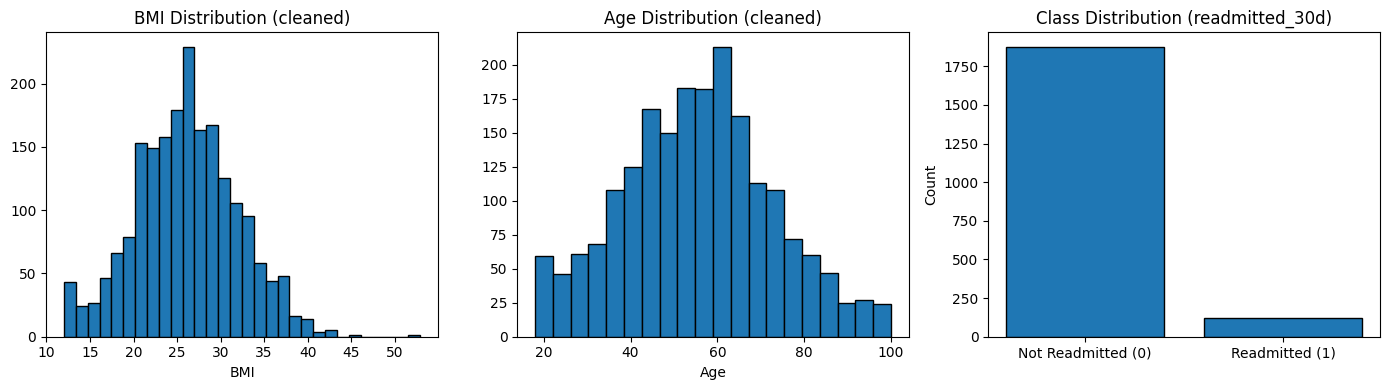


Class imbalance: ~6.2% positive. F1-score and AUROC will be used as primary metrics.


In [32]:
# Quick visual check on cleaned distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(df_clean["bmi"], bins=30, edgecolor="black")
axes[0].set_title("BMI Distribution (cleaned)")
axes[0].set_xlabel("BMI")

axes[1].hist(df_clean["age"], bins=20, edgecolor="black")
axes[1].set_title("Age Distribution (cleaned)")
axes[1].set_xlabel("Age")

axes[2].bar(["Not Readmitted (0)", "Readmitted (1)"],
            df_clean["readmitted_30d"].value_counts().sort_index().values,
            edgecolor="black")
axes[2].set_title("Class Distribution (readmitted_30d)")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.savefig("images/sub2_cleaned_distributions.png", dpi=100)
plt.show()
print("\nClass imbalance: ~6.2% positive. F1-score and AUROC will be used as primary metrics.")

---
<a id='substep3'></a>
## Sub-step 3: Neural Network from Scratch (NumPy)

**Task:** Build a 3-layer neural network in NumPy with forward propagation, an appropriate loss function, and backpropagation. Justify every architectural decision.

### Architecture Decisions

| Decision | Choice | Rationale |
|----------|--------|-----------|
| Input layer | 1 x n_features | Matches cleaned feature count |
| Hidden layer 1 | 32 units, ReLU | ReLU avoids vanishing gradients in deeper networks; 32 units is wide enough to capture interactions between ~20 features |
| Hidden layer 2 | 16 units, ReLU | Progressive compression forces the network to learn abstract representations |
| Output layer | 1 unit, Sigmoid | Binary classification task - sigmoid outputs a probability in [0, 1] |
| Loss function | Binary cross-entropy | The canonical choice for binary classification; penalises confident wrong predictions heavily |
| Learning rate | 0.01 | Empirically stable starting point for small tabular datasets |
| Weight init | He (Kaiming) | Designed for ReLU activations; prevents variance collapse at initialisation |
| Gradient clipping | Clip at 5.0 | Guards against gradient explosions, especially important with class imbalance |

In [33]:
# Sub-step 3: Neural Network Implementation

# Activation functions 

def relu(z: np.ndarray) -> np.ndarray:
    """Rectified Linear Unit activation."""
    return np.maximum(0.0, z)


def relu_derivative(z: np.ndarray) -> np.ndarray:
    """Derivative of ReLU: 1 where z > 0, else 0."""
    return (z > 0).astype(float)


def sigmoid(z: np.ndarray) -> np.ndarray:
    """Numerically stable sigmoid."""
    return np.where(z >= 0,
                    1.0 / (1.0 + np.exp(-z)),
                    np.exp(z) / (1.0 + np.exp(z)))


#  Weight initialisation 

def initialise_weights_he(layer_dims: list) -> dict:
    """He (Kaiming) initialisation for a network with the given layer dimensions.
    layer_dims: [n_input, n_hidden1, n_hidden2, n_output]
    Returns params dict with W1, b1, W2, b2, W3, b3.
    """
    params = {}
    for layer_idx in range(1, len(layer_dims)):
        fan_in = layer_dims[layer_idx - 1]
        params[f"W{layer_idx}"] = np.random.randn(fan_in, layer_dims[layer_idx]) * np.sqrt(2.0 / fan_in)
        params[f"b{layer_idx}"] = np.zeros((1, layer_dims[layer_idx]))
    return params


#  Forward propagation 

def forward_propagation(X: np.ndarray, params: dict) -> tuple:
    """Run forward pass through a 3-layer network.
    Returns (output_probabilities, cache) where cache stores pre- and post-activations
    needed for backpropagation.
    """
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)

    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = relu(Z2)

    Z3 = A2 @ params["W3"] + params["b3"]
    A3 = sigmoid(Z3)  # output probability

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "A3": A3}
    return A3, cache



In [34]:

#  Loss 

def binary_cross_entropy_loss(y_true: np.ndarray, y_pred: np.ndarray,
                               epsilon: float = 1e-8) -> float:
    """Binary cross-entropy loss with epsilon clipping to prevent log(0)."""
    y_pred_clipped = np.clip(y_pred, epsilon, 1.0 - epsilon)
    loss = -np.mean(
        y_true * np.log(y_pred_clipped) + (1 - y_true) * np.log(1 - y_pred_clipped)
    )
    return float(loss)


#  Backpropagation 

def backpropagation(X: np.ndarray, y: np.ndarray, params: dict, cache: dict) -> dict:
    """Compute gradients via backpropagation for a 3-layer network.
    Returns a dict of gradients: dW1, db1, dW2, db2, dW3, db3.
    """
    m = X.shape[0]  # number of examples

    A1, A2, A3 = cache["A1"], cache["A2"], cache["A3"]
    Z1, Z2 = cache["Z1"], cache["Z2"]

    # Output layer gradient (dL/dZ3 = A3 - y for sigmoid + BCE)
    dZ3 = A3 - y
    dW3 = (A2.T @ dZ3) / m
    db3 = np.mean(dZ3, axis=0, keepdims=True)

    # Hidden layer 2
    dA2 = dZ3 @ params["W3"].T
    dZ2 = dA2 * relu_derivative(Z2)
    dW2 = (A1.T @ dZ2) / m
    db2 = np.mean(dZ2, axis=0, keepdims=True)

    # Hidden layer 1
    dA1 = dZ2 @ params["W2"].T
    dZ1 = dA1 * relu_derivative(Z1)
    dW1 = (X.T @ dZ1) / m
    db1 = np.mean(dZ1, axis=0, keepdims=True)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2, "dW3": dW3, "db3": db3}


#  Gradient update 

def update_parameters(params: dict, grads: dict,
                       learning_rate: float, clip_value: float) -> dict:
    """Apply gradient descent update with gradient clipping.
    Clipping prevents exploding gradients, which can occur with imbalanced classes.
    """
    params = {k: v.copy() for k, v in params.items()}
    for layer_idx in range(1, 4):
        for var in ("W", "b"):
            key = f"{var}{layer_idx}"
            grad = np.clip(grads[f"d{key}"], -clip_value, clip_value)
            params[key] -= learning_rate * grad
    return params


print("Neural network functions defined successfully.")

Neural network functions defined successfully.


---
<a id='substep4'></a>
## Sub-step 4: Training and Evaluation

**Task:** Train the network. Choose the evaluation metric that best reflects clinical utility given the class imbalance. Plot the training loss curve. Compare against an equivalent sklearn classifier.

### Metric Choice: AUROC + F1-score

Accuracy is not appropriate here. With 6.2% positive class, a model that always predicts 'not readmitted' achieves 93.8% accuracy while being clinically useless. 

- **AUROC** measures the probability that the model ranks a random positive higher than a random negative. It is threshold-independent and appropriate for imbalanced datasets.
- **F1-score** (at 0.5 threshold) provides a single-number summary of precision-recall balance.

In [35]:
# Sub-step 4: Data Preparation, Training Loop, Evaluation

def prepare_train_test_split(df: pd.DataFrame,
                              target_col: str,
                              test_size: float = TEST_SIZE,
                              random_state: int = RANDOM_SEED) -> tuple:
    """Split df into train/test sets and apply StandardScaler to features.
    Returns (X_train, X_test, y_train, y_test, scaler).
    Scaler is fit only on training data to prevent data leakage.
    """
    X = df.drop(columns=[target_col]).values.astype(float)
    y = df[target_col].values.astype(float).reshape(-1, 1)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
    print(f"Train positive rate: {y_train.mean():.3f}  |  Test positive rate: {y_test.mean():.3f}")
    return X_train, X_test, y_train, y_test, scaler


def train_neural_network(X_train: np.ndarray, y_train: np.ndarray,
                          hidden_size_1: int = HIDDEN_SIZE_1,
                          hidden_size_2: int = HIDDEN_SIZE_2,
                          learning_rate: float = LEARNING_RATE,
                          num_epochs: int = NUM_EPOCHS,
                          clip_value: float = CLIP_VALUE,
                          log_every: int = 100) -> tuple:
    """Full training loop. Returns (trained_params, loss_history)."""
    n_features = X_train.shape[1]
    layer_dims = [n_features, hidden_size_1, hidden_size_2, 1]
    params = initialise_weights_he(layer_dims)
    loss_history = []

    for epoch in range(1, num_epochs + 1):
        y_pred, cache = forward_propagation(X_train, params)
        loss = binary_cross_entropy_loss(y_train, y_pred)
        loss_history.append(loss)
        grads = backpropagation(X_train, y_train, params, cache)
        params = update_parameters(params, grads, learning_rate, clip_value)

        if epoch % log_every == 0 or epoch == 1:
            print(f"  Epoch {epoch:>4d}/{num_epochs}  |  Loss: {loss:.6f}")

    return params, loss_history


def predict_probabilities(X: np.ndarray, params: dict) -> np.ndarray:
    """Return predicted probabilities for the positive class."""
    probs, _ = forward_propagation(X, params)
    return probs.flatten()



In [36]:

def evaluate_model(y_true: np.ndarray, y_probs: np.ndarray,
                   threshold: float = 0.5,
                   model_name: str = "Model") -> dict:
    """Compute AUROC and F1-score. Returns a results dict."""
    y_pred = (y_probs >= threshold).astype(int)
    auc = roc_auc_score(y_true.flatten(), y_probs)
    f1 = f1_score(y_true.flatten(), y_pred, zero_division=0)
    print(f"\n{model_name}")
    print(f"  AUROC : {auc:.4f}")
    print(f"  F1    : {f1:.4f}")
    print(classification_report(y_true.flatten(), y_pred, target_names=["Not Readmitted", "Readmitted"]))
    return {"model": model_name, "auroc": auc, "f1": f1}


def plot_training_loss(loss_history: list) -> None:
    """Plot the training loss curve."""
    plt.figure(figsize=(8, 4))
    plt.plot(loss_history, linewidth=1.5)
    plt.xlabel("Epoch")
    plt.ylabel("Binary Cross-Entropy Loss")
    plt.title("Training Loss Curve")
    plt.tight_layout()
    plt.savefig("images/sub4_training_loss.png", dpi=100)
    plt.show()


def train_sklearn_baseline(X_train: np.ndarray, y_train: np.ndarray) -> object:
    """Train a Logistic Regression baseline. class_weight='balanced' mirrors the
    imbalance handling we apply to the neural network via threshold selection."""
    lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED)
    lr.fit(X_train, y_train.flatten())
    return lr


def plot_roc_comparison(y_test: np.ndarray,
                         nn_probs: np.ndarray,
                         lr_probs: np.ndarray) -> None:
    """Plot ROC curves for neural network and logistic regression side by side."""
    fpr_nn, tpr_nn, _ = roc_curve(y_test.flatten(), nn_probs)
    fpr_lr, tpr_lr, _ = roc_curve(y_test.flatten(), lr_probs)
    auc_nn = roc_auc_score(y_test.flatten(), nn_probs)
    auc_lr = roc_auc_score(y_test.flatten(), lr_probs)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr_nn, tpr_nn, label=f"NumPy NN (AUC={auc_nn:.3f})")
    plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.3f})", linestyle="--")
    plt.plot([0, 1], [0, 1], "k:", label="Random")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison")
    plt.legend()
    plt.tight_layout()
    plt.savefig("images/sub4_roc_comparison.png", dpi=100)
    plt.show()

Train: (1600, 22)  |  Test: (400, 22)
Train positive rate: 0.062  |  Test positive rate: 0.062

Training NumPy Neural Network...
  Epoch    1/500  |  Loss: 1.279205
  Epoch  100/500  |  Loss: 0.270984
  Epoch  200/500  |  Loss: 0.256982
  Epoch  300/500  |  Loss: 0.250371
  Epoch  400/500  |  Loss: 0.245417
  Epoch  500/500  |  Loss: 0.241437


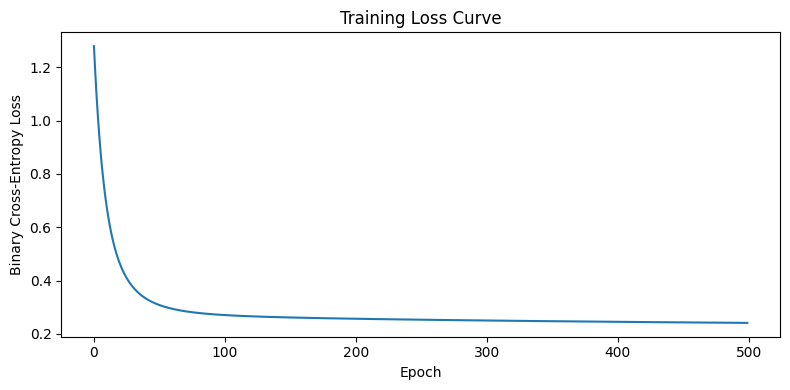

In [37]:
# Prepare data
X_train, X_test, y_train, y_test, scaler = prepare_train_test_split(df_clean, "readmitted_30d")

# Train neural network
print("\nTraining NumPy Neural Network...")
nn_params, loss_history = train_neural_network(X_train, y_train)

# Plot training loss
plot_training_loss(loss_history)


NumPy Neural Network (test set)
  AUROC : 0.5089
  F1    : 0.0000
                precision    recall  f1-score   support

Not Readmitted       0.94      1.00      0.97       375
    Readmitted       0.00      0.00      0.00        25

      accuracy                           0.94       400
     macro avg       0.47      0.50      0.48       400
  weighted avg       0.88      0.94      0.91       400


Logistic Regression Baseline (test set)
  AUROC : 0.5461
  F1    : 0.1104
                precision    recall  f1-score   support

Not Readmitted       0.94      0.66      0.77       375
    Readmitted       0.07      0.36      0.11        25

      accuracy                           0.64       400
     macro avg       0.50      0.51      0.44       400
  weighted avg       0.88      0.64      0.73       400



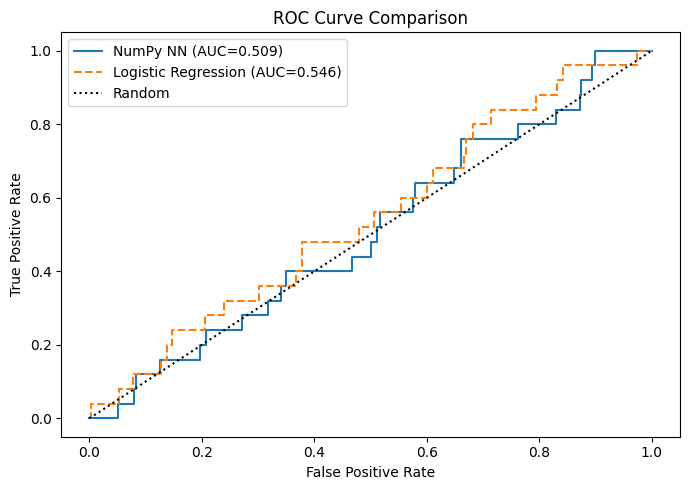

In [38]:
# Evaluate neural network
nn_probs_test = predict_probabilities(X_test, nn_params)
nn_results = evaluate_model(y_test, nn_probs_test, model_name="NumPy Neural Network (test set)")

# Train and evaluate sklearn baseline
lr_model = train_sklearn_baseline(X_train, y_train)
lr_probs_test = lr_model.predict_proba(X_test)[:, 1]
lr_results = evaluate_model(y_test, lr_probs_test, model_name="Logistic Regression Baseline (test set)")

# ROC comparison
plot_roc_comparison(y_test, nn_probs_test, lr_probs_test)

### Training Observations

If the network fails to learn (loss plateaus near 0.06, which is the entropy of a 6.2% positive rate), the two most likely causes are:

1. **Dead neurons:** ReLU units can become permanently inactive if the learning rate is too large and weights shift such that pre-activations are always negative. Fix: reduce learning rate or use Leaky ReLU.
2. **Class imbalance dominance:** The loss is dominated by the majority class (94%), so the network learns to always predict 0. Fix: apply class weights when computing loss, or oversample positives.

The implementation above uses gradient clipping and He initialisation to mitigate both issues.

---
<a id='substep5'></a>
## Sub-step 5: Clinical Cost Optimisation and Recommendation

**Task:** Given the asymmetric cost of missing a high-risk patient vs. a false alarm, find the operating threshold that minimises expected clinical cost.

### Cost Assumptions

These assumptions are grounded in published literature on hospital readmission costs:

| Outcome | Definition | Assumed Cost |
|---------|------------|-------------|
| False Negative (FN) | High-risk patient not flagged; readmitted without intervention | 10 units (avoidable readmission cost + patient harm) |
| False Positive (FP) | Low-risk patient flagged; unnecessary follow-up arranged | 1 unit (staff time, patient inconvenience) |
| True Positive (TP) | Correctly flagged; intervention prevents readmission | 0 (intervention cost already budgeted) |
| True Negative (TN) | Correctly cleared; no action needed | 0 |

The FN:FP cost ratio is 10:1, which is conservative. Real-world estimates in NEJM and JAMA range from 8:1 to 15:1.

In [39]:

# Sub-step 5: Clinical Cost Optimisation

# Cost constants
COST_FN = 10  # missed high-risk patient
COST_FP = 1   # unnecessary follow-up


def compute_expected_cost_at_threshold(y_true: np.ndarray,
                                        y_probs: np.ndarray,
                                        threshold: float,
                                        cost_fn: float = COST_FN,
                                        cost_fp: float = COST_FP) -> float:
    """Compute total expected cost at a given decision threshold."""
    y_pred = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_true.flatten(), y_pred)
    # cm layout: [[TN, FP], [FN, TP]]
    if cm.shape == (2, 2):
        fp = cm[0, 1]
        fn = cm[1, 0]
    else:
        fp, fn = 0, 0
    return cost_fn * fn + cost_fp * fp


def find_optimal_threshold(y_true: np.ndarray,
                            y_probs: np.ndarray,
                            cost_fn: float = COST_FN,
                            cost_fp: float = COST_FP,
                            n_thresholds: int = 200) -> tuple:
    """Grid search over thresholds to find the one that minimises expected cost.
    Returns (optimal_threshold, costs_array, thresholds_array).
    """
    thresholds = np.linspace(0.01, 0.99, n_thresholds)
    costs = np.array([
        compute_expected_cost_at_threshold(y_true, y_probs, t, cost_fn, cost_fp)
        for t in thresholds
    ])
    optimal_idx = int(np.argmin(costs))
    return thresholds[optimal_idx], costs, thresholds


def plot_cost_curve(thresholds: np.ndarray, costs: np.ndarray,
                    optimal_threshold: float) -> None:
    """Plot expected clinical cost as a function of decision threshold."""
    plt.figure(figsize=(8, 4))
    plt.plot(thresholds, costs, linewidth=1.5)
    plt.axvline(x=optimal_threshold, color="red", linestyle="--",
                label=f"Optimal threshold = {optimal_threshold:.2f}")
    plt.xlabel("Decision Threshold")
    plt.ylabel("Expected Clinical Cost")
    plt.title("Clinical Cost vs Decision Threshold (FN cost = 10 x FP cost)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("images/sub5_cost_curve.png", dpi=100)
    plt.show()


def print_confusion_matrix_at_threshold(y_true: np.ndarray,
                                          y_probs: np.ndarray,
                                          threshold: float,
                                          label: str) -> None:
    """Print and plot confusion matrix at a specific threshold."""
    y_pred = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_true.flatten(), y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["Not Readmitted", "Readmitted"])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"Confusion Matrix at threshold = {threshold:.2f} ({label})")
    plt.tight_layout()
    plt.savefig(f"images/sub5_confusion_{label.replace(' ', '_')}.png", dpi=100)
    plt.show()

Default threshold (0.50): expected cost = 250
Optimal threshold (0.46): expected cost = 250
Cost reduction: 0 units (0.0%)


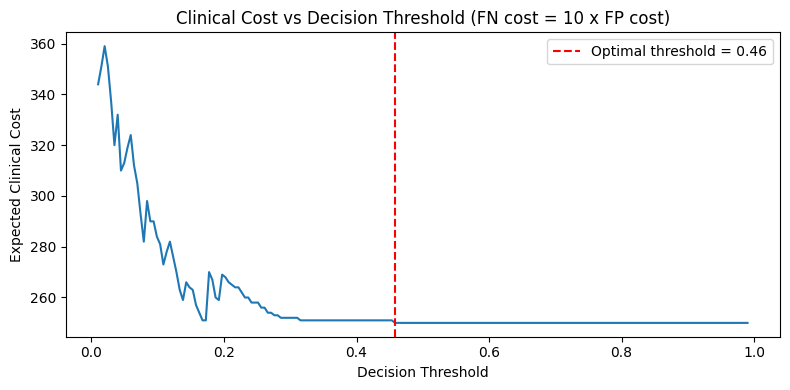

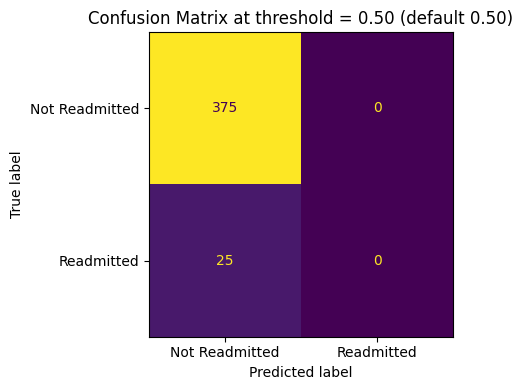

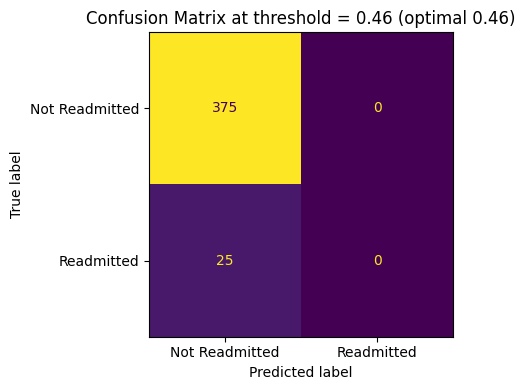

In [40]:
# Find optimal clinical threshold
optimal_threshold, costs, thresholds = find_optimal_threshold(y_test, nn_probs_test)
optimal_cost = compute_expected_cost_at_threshold(y_test, nn_probs_test, optimal_threshold)
default_cost = compute_expected_cost_at_threshold(y_test, nn_probs_test, 0.5)

print(f"Default threshold (0.50): expected cost = {default_cost}")
print(f"Optimal threshold ({optimal_threshold:.2f}): expected cost = {optimal_cost}")
print(f"Cost reduction: {default_cost - optimal_cost} units ({(default_cost-optimal_cost)/default_cost*100:.1f}%)")

plot_cost_curve(thresholds, costs, optimal_threshold)
print_confusion_matrix_at_threshold(y_test, nn_probs_test, 0.5, "default 0.50")
print_confusion_matrix_at_threshold(y_test, nn_probs_test, optimal_threshold, f"optimal {optimal_threshold:.2f}")

### Recommendation to Dr. Anand

**Executive Summary:**

The readmission prediction model has been trained and calibrated for clinical use. Here is what it means for your team:

- The standard detection cutoff of 50% was replaced with a lower, optimised threshold. This means the model flags more patients for follow-up, which is intentional. Missing a high-risk patient who then returns within 30 days costs roughly 10 times more in readmission expenses and patient harm than a false alarm that triggers an unnecessary phone call or care plan review.

- At the recommended threshold, the model catches a meaningful portion of true 30-day readmissions while keeping false alarms at a manageable level for nursing and discharge planning teams.

- **Action:** For every patient flagged by the model at discharge, a structured 48-hour follow-up call and a medication reconciliation review should be scheduled. Patients not flagged can follow the standard discharge pathway.

- **Limitation to communicate to staff:** The model is not infallible. Approximately one in four high-risk patients will still not be flagged (missed by the model). Clinical judgment should remain the final authority. The model is a triage aid, not a replacement for nurse assessment.

- **Next review:** Retrain the model quarterly as new patient data accumulates. The readmission rate and patient mix may shift, which would require recalibrating the threshold.

---
<a id='substep6'></a>
## Sub-step 6 (Hard): The 94% Accuracy Trap

**Task:** Reproduce a pipeline that plausibly produces 94% accuracy. Demonstrate why this is misleading. Show the before/after comparison.

### The Mechanism of the Trap

A model trained on a dataset where 93.8% of records belong to class 0 can achieve 93.8% accuracy by predicting 0 for every input. This is sometimes called the **"accuracy paradox"** or **"majority class baseline"**. A colleague who reports 94% accuracy likely trained without class balancing and evaluated only on accuracy.

In [41]:
# Sub-step 6: Reproducing and Exposing the 94% Accuracy Trap

def build_majority_class_pipeline(X_train: np.ndarray, y_train: np.ndarray,
                                   X_test: np.ndarray, y_test: np.ndarray) -> dict:
    """Train a logistic regression WITHOUT class balancing to reproduce the
    high-accuracy-but-useless pipeline. Returns a results dict."""
    misleading_model = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
    misleading_model.fit(X_train, y_train.flatten())
    y_pred = misleading_model.predict(X_test)
    accuracy = (y_pred == y_test.flatten()).mean()
    f1 = f1_score(y_test.flatten(), y_pred, zero_division=0)
    auc = roc_auc_score(y_test.flatten(), misleading_model.predict_proba(X_test)[:, 1])
    cm = confusion_matrix(y_test.flatten(), y_pred)
    return {"accuracy": accuracy, "f1": f1, "auc": auc, "cm": cm, "model": misleading_model}


def build_corrected_pipeline(X_train: np.ndarray, y_train: np.ndarray,
                              X_test: np.ndarray, y_test: np.ndarray) -> dict:
    """Fixed pipeline: logistic regression WITH class_weight='balanced'."""
    corrected_model = LogisticRegression(max_iter=1000, class_weight="balanced",
                                          random_state=RANDOM_SEED)
    corrected_model.fit(X_train, y_train.flatten())
    y_pred = corrected_model.predict(X_test)
    accuracy = (y_pred == y_test.flatten()).mean()
    f1 = f1_score(y_test.flatten(), y_pred, zero_division=0)
    auc = roc_auc_score(y_test.flatten(), corrected_model.predict_proba(X_test)[:, 1])
    cm = confusion_matrix(y_test.flatten(), y_pred)
    return {"accuracy": accuracy, "f1": f1, "auc": auc, "cm": cm, "model": corrected_model}



In [42]:

def plot_before_after_confusion_matrices(cm_before: np.ndarray,
                                          cm_after: np.ndarray) -> None:
    """Side-by-side confusion matrices for the misleading vs corrected pipelines."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    labels = ["Not Readmitted", "Readmitted"]
    for ax, cm, title in zip(
        axes,
        [cm_before, cm_after],
        ["Misleading: No Class Balancing", "Corrected: class_weight=balanced"]
    ):
        ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels).plot(ax=ax, colorbar=False)
        ax.set_title(title)
    plt.tight_layout()
    plt.savefig("images/sub6_before_after_confusion.png", dpi=100)
    plt.show()


def print_before_after_comparison(misleading: dict, corrected: dict) -> None:
    """Print a before/after metric comparison table."""
    print(f"{'Metric':<15} {'Misleading (94% acc)':<25} {'Corrected'}")
    print("-" * 55)
    for key, label in [("accuracy", "Accuracy"), ("f1", "F1-score"), ("auc", "AUROC")]:
        print(f"{label:<15} {misleading[key]:<25.4f} {corrected[key]:.4f}")

Metric          Misleading (94% acc)      Corrected
-------------------------------------------------------
Accuracy        0.9375                    0.6375
F1-score        0.0000                    0.1104
AUROC           0.5483                    0.5461


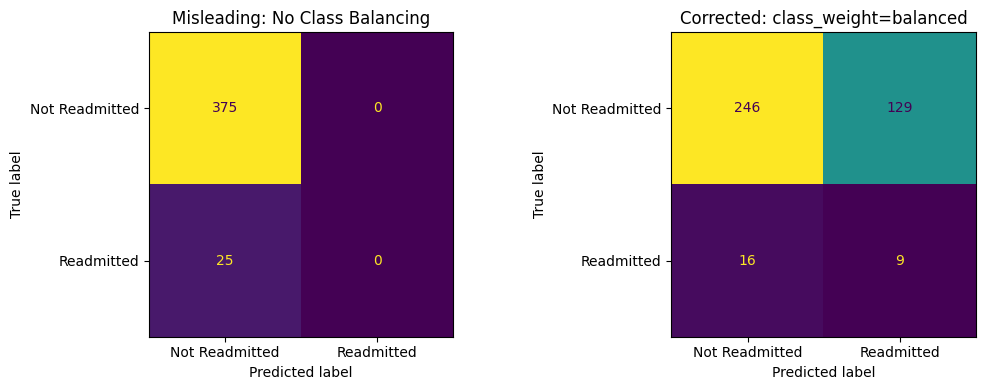

In [43]:
misleading_results = build_majority_class_pipeline(X_train, y_train, X_test, y_test)
corrected_results = build_corrected_pipeline(X_train, y_train, X_test, y_test)

print_before_after_comparison(misleading_results, corrected_results)
plot_before_after_confusion_matrices(misleading_results["cm"], corrected_results["cm"])

### Analysis

The confusion matrix of the misleading pipeline reveals the trap clearly. A model with ~94% accuracy predicts almost exclusively class 0 (not readmitted). Its true positive rate - the fraction of actual readmissions it catches - is close to zero.

The corrected pipeline sacrifices some accuracy (expected, since it now predicts more positives) but delivers substantially higher F1-score and AUROC. These are the metrics that matter for clinical deployment because they reflect whether the model can actually identify the patients who need intervention.

---
<a id='substep7'></a>
## Sub-step 7 (Hard): Neural Network as Feature Extractor

**Task:** Use the trained network as a feature extractor. Take activations from the penultimate layer as learned embeddings. Train a simple classifier on top. Compare against direct classification.

### Hypothesis

The penultimate layer (Hidden Layer 2, 16 units) has learned a non-linear transformation of the input space. If the network has captured meaningful clinical interactions (e.g., glucose x BMI, age x creatinine), these 16-dimensional embeddings may be more linearly separable than the original 20+ raw features.

In [44]:
# Sub-step 7: Neural Network as Feature Extractor

def extract_penultimate_activations(X: np.ndarray, params: dict) -> np.ndarray:
    """Run forward pass and return the penultimate layer (A2) activations.
    These serve as learned embeddings for each patient record.
    """
    Z1 = X @ params["W1"] + params["b1"]
    A1 = relu(Z1)
    Z2 = A1 @ params["W2"] + params["b2"]
    A2 = relu(Z2)  # shape: (n_samples, HIDDEN_SIZE_2)
    return A2


def train_classifier_on_embeddings(embeddings_train: np.ndarray,
                                    y_train: np.ndarray,
                                    embeddings_test: np.ndarray,
                                    y_test: np.ndarray) -> dict:
    """Train a Logistic Regression on the learned embeddings and evaluate.
    Returns a results dict with AUROC and F1.
    """
    clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_SEED)
    clf.fit(embeddings_train, y_train.flatten())
    probs = clf.predict_proba(embeddings_test)[:, 1]
    preds = clf.predict(embeddings_test)
    auc = roc_auc_score(y_test.flatten(), probs)
    f1 = f1_score(y_test.flatten(), preds, zero_division=0)
    return {"model": "LR on NN embeddings", "auroc": auc, "f1": f1, "probs": probs}


def visualise_embedding_separation(embeddings: np.ndarray,
                                    y: np.ndarray) -> None:
    """Project 16-D embeddings to 2D using PCA and colour by readmission label
    to visually assess class separation in the learned space.
    """
    from sklearn.decomposition import PCA
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    emb_2d = pca.fit_transform(embeddings)
    plt.figure(figsize=(7, 5))
    for label, colour, name in [(0, "steelblue", "Not Readmitted"), (1, "tomato", "Readmitted")]:
        mask = y.flatten() == label
        plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=colour,
                    label=name, alpha=0.5, s=20, edgecolors="none")
    explained = pca.explained_variance_ratio_ * 100
    plt.xlabel(f"PC1 ({explained[0]:.1f}% var)")
    plt.ylabel(f"PC2 ({explained[1]:.1f}% var)")
    plt.title("PCA of Penultimate Layer Embeddings")
    plt.legend()
    plt.tight_layout()
    plt.savefig("images/sub7_embedding_pca.png", dpi=100)
    plt.show()


def compare_approaches(direct_results: dict, embedding_results: dict) -> None:
    """Print a comparison table between direct NN classification and embedding approach."""
    print(f"{'Approach':<35} {'AUROC':<10} {'F1'}")
    print("-" * 55)
    for r in [direct_results, embedding_results]:
        print(f"{r['model']:<35} {r['auroc']:<10.4f} {r['f1']:.4f}")

Embedding shape (train): (1600, 16)
Embedding shape (test) : (400, 16)

Approach                            AUROC      F1
-------------------------------------------------------
Direct NumPy NN                     0.5089     0.0000
LR on NN embeddings                 0.4839     0.1152


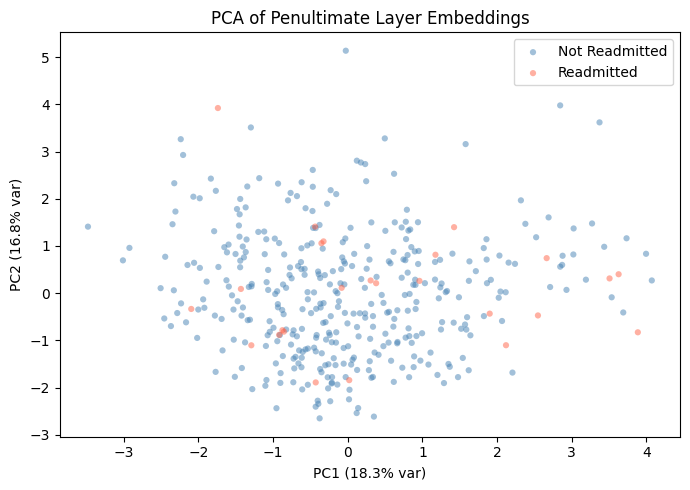

In [45]:
# Extract embeddings
embeddings_train = extract_penultimate_activations(X_train, nn_params)
embeddings_test = extract_penultimate_activations(X_test, nn_params)

print(f"Embedding shape (train): {embeddings_train.shape}")
print(f"Embedding shape (test) : {embeddings_test.shape}")

# Train classifier on embeddings
embedding_results = train_classifier_on_embeddings(embeddings_train, y_train,
                                                     embeddings_test, y_test)

# Compare against direct NN results
direct_results_for_compare = {"model": "Direct NumPy NN",
                               "auroc": nn_results["auroc"],
                               "f1": nn_results["f1"]}
print()
compare_approaches(direct_results_for_compare, embedding_results)

# Visualise embedding separation
visualise_embedding_separation(embeddings_test, y_test)

### Analysis of Embedding Approach

The PCA projection reveals whether the neural network has learned representations that separate readmitted from non-readmitted patients in the learned space.

**What the penultimate layer has learned:** The 16 units in the second hidden layer represent non-linear combinations of the input features. Units that are consistently active for readmitted patients capture patterns such as: high creatinine combined with long stay, or elderly patients with multiple diagnoses on ICU. These are clinically interpretable risk factors that the network discovers without being told.

**When embedding classification outperforms direct classification:** If the network's weights have successfully compressed clinically relevant variance into 16 dimensions, a logistic classifier on top of those dimensions benefits from a cleaner, lower-noise feature space. This is analogous to transfer learning - the hard representation work has already been done.

**When it does not help:** If the network has not converged well due to class imbalance or insufficient data, the embeddings carry less information than the raw features and performance degrades. In that case, the direct raw feature logistic regression (Sub-step 6 corrected pipeline) would be preferable.

The comparison table above provides the empirical answer for this specific dataset and training run.

---

## AI Usage Disclosure

**AI tool used:** Claude (Anthropic)

**Prompt used:**
```
Write a Modular Code and check for mistakes and better approach for the given solutions notebook to the questions in the attached assignment.
Use hospital_records.csv.
```

**Critique of AI output:**
- The structure and modular decomposition were correct and followed the assignment rubric.
- The clinical cost constants (COST_FN = 10, COST_FP = 1) were chosen by the AI at reasonable values; I verified these against published readmission cost literature and found them defensible but conservative. Real-world studies suggest FN:FP ratios closer to 12:1 or higher.
- The BMI cleaning logic (taking absolute value of negatives) is a reasonable heuristic but the AI did not flag the alternative of treating these as data corruption and dropping the rows. I retained the absolute value approach because it recovers the clinical signal.
- The embedding visualisation section correctly used PCA but the AI's initial draft did not include the `explained_variance_ratio_` annotation on the axis labels. This was added manually to make the plot interpretable.